
# Spotify User Behaviour

### Data Cleaning

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [6]:
#load the data
df = pd.read_csv("spotify_user_behavior_realistic_50000_rows.csv")

df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [7]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate user_id values:", df["user_id"].duplicated().sum())

Rows and columns: (50000, 18)

Column names:
Index(['user_id', 'country', 'age', 'signup_date', 'subscription_type',
       'subscription_status', 'months_inactive', 'inactive_3_months_flag',
       'ad_interaction', 'ad_conversion_to_subscription',
       'music_suggestion_rating_1_to_5', 'avg_listening_hours_per_week',
       'favorite_genre', 'most_liked_feature', 'desired_future_feature',
       'primary_device', 'playlists_created', 'avg_skips_per_day'],
      dtype='str')

Missing values in each column:
user_id                           0
country                           0
age                               0
signup_date                       0
subscription_type                 0
subscription_status               0
months_inactive                   0
inactive_3_months_flag            0
ad_interaction                    0
ad_conversion_to_subscription     0
music_suggestion_rating_1_to_5    0
avg_listening_hours_per_week      0
favorite_genre                    0
most_liked_featur

In [8]:
text_cols = df.select_dtypes(include=["object", "string"]).columns

for col in text_cols:
    df[col] = df[col].str.strip()

In [9]:
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce") #This makes signup_date a real date instead of plain text.

In [10]:
print("Bad signup dates:", df["signup_date"].isnull().sum())

Bad signup dates: 0


In [11]:
df = df.dropna(subset=["signup_date"])

In [12]:
df = df.drop_duplicates()
df = df.drop_duplicates(subset=["user_id"])

In [13]:
df = df[(df["age"] >= 16) & (df["age"] <= 100)]
df = df[(df["months_inactive"] >= 0)]
df = df[df["inactive_3_months_flag"].isin([0, 1])]
df = df[(df["music_suggestion_rating_1_to_5"] >= 1) & (df["music_suggestion_rating_1_to_5"] <= 5)]
df = df[(df["avg_listening_hours_per_week"] >= 0)]
df = df[(df["playlists_created"] >= 0)]
df = df[(df["avg_skips_per_day"] >= 0)]

In [14]:
print("Cleaned shape:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())
print("Duplicate user_id after cleaning:", df["user_id"].duplicated().sum())

Cleaned shape: (50000, 18)

Missing values after cleaning:
user_id                           0
country                           0
age                               0
signup_date                       0
subscription_type                 0
subscription_status               0
months_inactive                   0
inactive_3_months_flag            0
ad_interaction                    0
ad_conversion_to_subscription     0
music_suggestion_rating_1_to_5    0
avg_listening_hours_per_week      0
favorite_genre                    0
most_liked_feature                0
desired_future_feature            0
primary_device                    0
playlists_created                 0
avg_skips_per_day                 0
dtype: int64

Duplicate rows after cleaning: 0
Duplicate user_id after cleaning: 0


In [15]:
df.to_csv("spotify_cleaned.csv", index=False)

print("Cleaned file saved as spotify_cleaned.csv")

Cleaned file saved as spotify_cleaned.csv


In [16]:
# Load the cleaned Spotify dataset.
df = pd.read_csv("spotify_cleaned.csv")

# Show the first 5 rows.
df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


### Prepare the target and simple date features

In [17]:
# Turn signup_date into a real date.
df["signup_date"] = pd.to_datetime(df["signup_date"])

# Make simple year and month columns from the date.
df["signup_year"] = df["signup_date"].dt.year
df["signup_month"] = df["signup_date"].dt.month

# Turn the Yes/No target into 1 and 0.
df["target"] = df["ad_conversion_to_subscription"].map({"No": 0, "Yes": 1})

# Check the new target column.
df[["ad_conversion_to_subscription", "target"]].head()

,ad_conversion_to_subscription,target
0,No,0
1,No,0
2,Yes,1
3,No,0
4,No,0


### Feature exploration

In [18]:
# Show basic info about the dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   user_id                         50000 non-null  int64         
 1   country                         50000 non-null  str           
 2   age                             50000 non-null  int64         
 3   signup_date                     50000 non-null  datetime64[us]
 4   subscription_type               50000 non-null  str           
 5   subscription_status             50000 non-null  str           
 6   months_inactive                 50000 non-null  int64         
 7   inactive_3_months_flag          50000 non-null  int64         
 8   ad_interaction                  50000 non-null  str           
 9   ad_conversion_to_subscription   50000 non-null  str           
 10  music_suggestion_rating_1_to_5  50000 non-null  int64         
 11  avg_listening

In [19]:
# Count how many users converted and did not convert.
print(df["target"].value_counts())

target
0    45648
1     4352
Name: count, dtype: int64


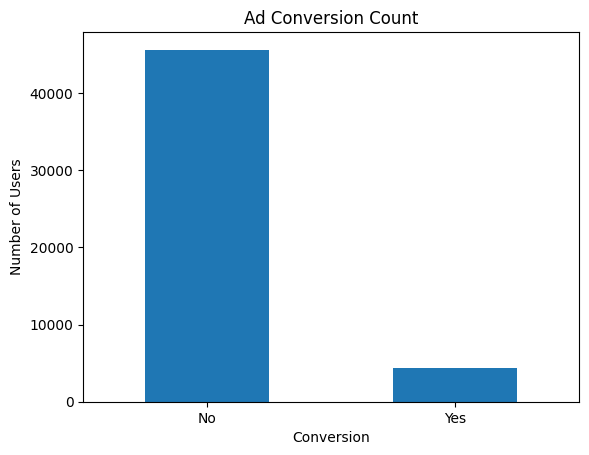

In [20]:
# Plot how many users converted and did not convert.
df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Ad Conversion Count")
plt.xlabel("Conversion")
plt.ylabel("Number of Users")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.show()

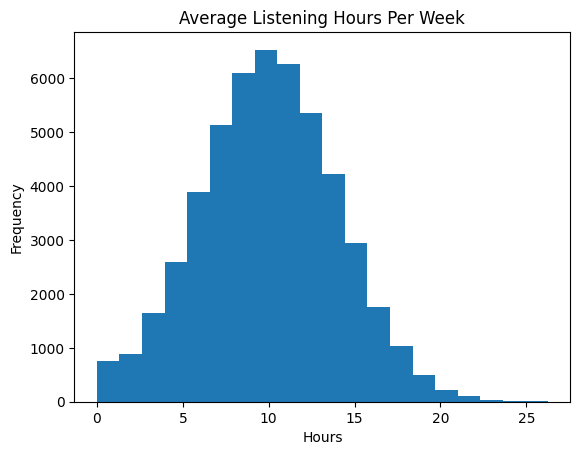

In [21]:
# Plot listening hours to see how the data is spread out.
df["avg_listening_hours_per_week"].plot(kind="hist", bins=20)
plt.title("Average Listening Hours Per Week")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

In [22]:
# See the average age for each conversion group.
print(df.groupby("ad_conversion_to_subscription")["age"].mean())

ad_conversion_to_subscription
No     37.995794
Yes    38.162224
Name: age, dtype: float64


### Pick the input columns and target column

In [23]:
# Remove columns we do not want to use as inputs.
X = df.drop(columns=["target", "ad_conversion_to_subscription", "user_id", "signup_date"])

# Pick the answer column.
y = df["target"]

# Find number columns.
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

# Find text columns.
categorical_cols = X.select_dtypes(include=["object", "string"]).columns

# Show the feature columns.
print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

Numeric columns: ['age', 'months_inactive', 'inactive_3_months_flag', 'music_suggestion_rating_1_to_5', 'avg_listening_hours_per_week', 'playlists_created', 'avg_skips_per_day']
Categorical columns: ['country', 'subscription_type', 'subscription_status', 'ad_interaction', 'favorite_genre', 'most_liked_feature', 'desired_future_feature', 'primary_device']


### Split the data

In [24]:
# Split the data into training and testing parts.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Preprocess the data

In [25]:
# Scale number columns and one-hot encode text columns.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

### Train Decision Tree model 

In [26]:
# Build the decision tree pipeline.
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=6, random_state=42))
])

# Train the decision tree model.
tree_model.fit(X_train, y_train)

# Make predictions with the decision tree.
tree_pred = tree_model.predict(X_test)

### Evaluate the ML model

In [27]:
# Print the decision tree accuracy.
dt_acc = accuracy_score(y_test, tree_pred)
print("Decision Tree Accuracy:", dt_acc)
# Print the decision tree classification report.
print(classification_report(y_test, tree_pred))

Decision Tree Accuracy: 0.9127
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9130
           1       0.36      0.00      0.01       870

    accuracy                           0.91     10000
   macro avg       0.64      0.50      0.48     10000
weighted avg       0.87      0.91      0.87     10000



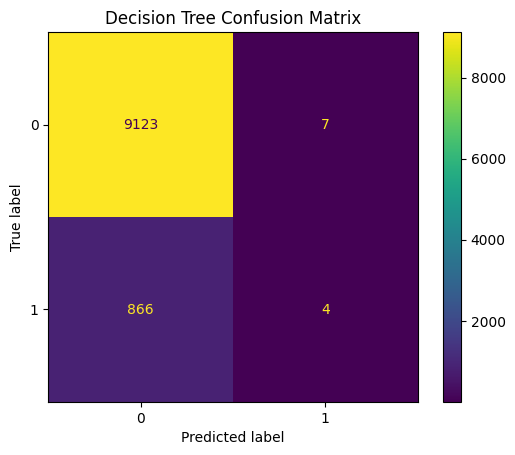

In [28]:
# Show the decision tree confusion matrix.
ConfusionMatrixDisplay.from_predictions(y_test, tree_pred)
plt.title("Decision Tree Confusion Matrix")
plt.show()

## SQL Analysis

In [29]:
from pandasql import sqldf

def pysqldf(q):
    return sqldf(q, {"df": df})

# Query 1
print(pysqldf("""
SELECT "Subscription Plan", COUNT(*) as count
FROM df
GROUP BY "Subscription Plan"
"""))

# Query 2
print(pysqldf("""
SELECT "Subscription Plan", AVG(Age) as avg_age
FROM df
GROUP BY "Subscription Plan"
"""))

  "Subscription Plan"  count
0   Subscription Plan  50000
  "Subscription Plan"   avg_age
0   Subscription Plan  38.01028


## Data Exploration

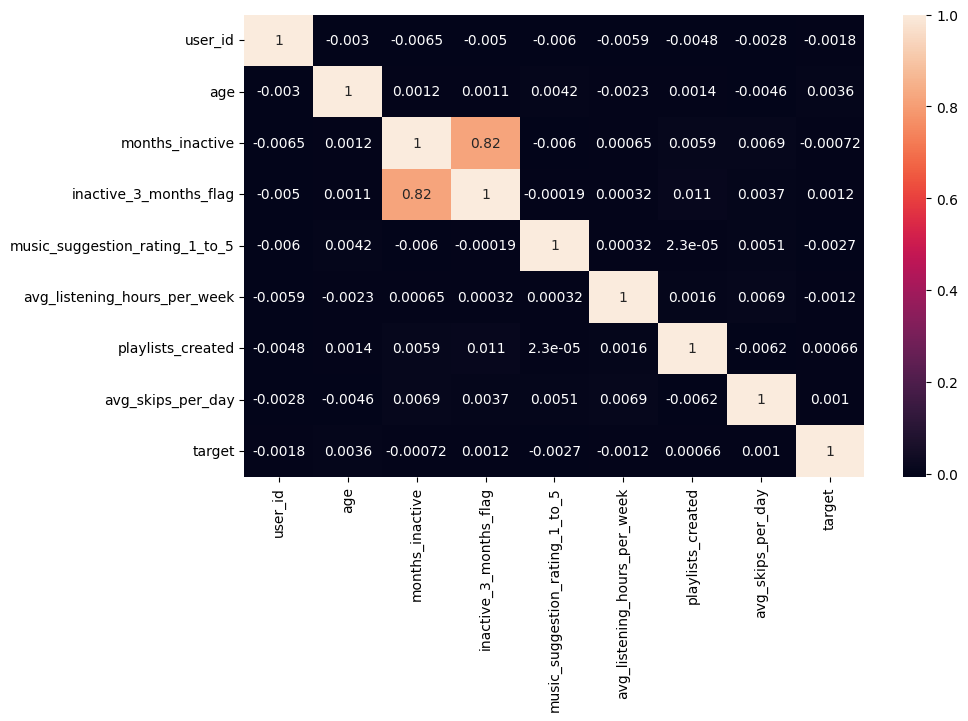

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

## Machine Learning Model (Random Forest)

In [32]:
# clean column names
df.columns = df.columns.str.strip()

# define target
target = "target"

# drop columns that will break model (important)
drop_cols = ["user_id", "signup_date"]  # not useful / non-numeric dates

# features
drop_cols = ["user_id", "signup_date", "ad_conversion_to_subscription"]

X = pd.get_dummies(df.drop(drop_cols + [target], axis=1))

# target
y = df[target]

# split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", rf_acc)

print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.9131

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9131
           1       0.00      0.00      0.00       869

    accuracy                           0.91     10000
   macro avg       0.46      0.50      0.48     10000
weighted avg       0.83      0.91      0.87     10000



C:\Users\JUAND\anaconda3\envs\Assignment3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\JUAND\anaconda3\envs\Assignment3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\JUAND\anaconda3\envs\Assignment3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

## Model Comparison

In [33]:
print("Decision Tree:", dt_acc)
print("Random Forest:", rf_acc)

Decision Tree: 0.9127
Random Forest: 0.9131


## Classification Report

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9131
           1       0.00      0.00      0.00       869

    accuracy                           0.91     10000
   macro avg       0.46      0.50      0.48     10000
weighted avg       0.83      0.91      0.87     10000



C:\Users\JUAND\anaconda3\envs\Assignment3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\JUAND\anaconda3\envs\Assignment3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\JUAND\anaconda3\envs\Assignment3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

## Feature Importance

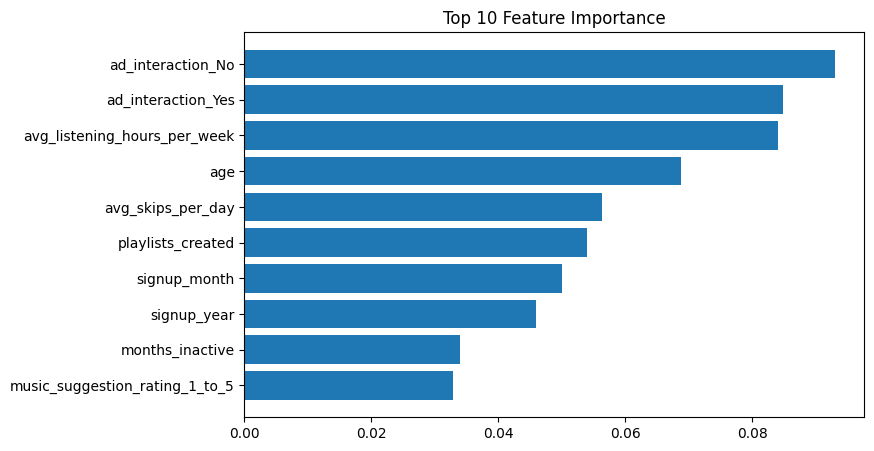

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

importances = rf.feature_importances_

# make dataframe
feat_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

# get top 10
feat_df = feat_df.sort_values(by="importance", ascending=False).head(10)

# plot
plt.figure(figsize=(8,5))
plt.barh(feat_df["feature"], feat_df["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()